In [16]:
!pip install bitsandbytes --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 52.8 MB/s eta 0:00:00:00:0100:01


In [1]:
import pandas as pd 
import numpy as np

# 1. Data Preparation and LLM/SLM-based Enrichment

In [10]:
# Loading the Dataset (Generated from Claude and saved into a public repo on GitHub)

url = "https://raw.githubusercontent.com/RichieMonkeyNinja/public-dm-finals/main/student_engagement_data(1).csv"

df = pd.read_csv(url)
df.head()

,StudentID,Age,Program,YearOfStudy,AttendanceRate,LMS_LoginFrequency,AssignmentSubmissionRate,AvgScore,ForumParticipation,EngagementLevel
0,S001,19.0,Computer Science,1.0,92.0,28.0,95.0,88.0,12.0,High
1,S002,21.0,Business Administration,2.0,65.0,10.0,70.0,NaN,3.0,Medium
2,S003,23.0,Data Science,3.0,40.0,5.0,45.0,50.0,NaN,Low
3,S004,20.0,Mechanical Engineering,2.0,88.0,NaN,90.0,84.0,9.0,High
4,S005,22.0,Psychology,3.0,NaN,12.0,60.0,58.0,2.0,Medium


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   StudentID                 50 non-null     object 
 1   Age                       49 non-null     float64
 2   Program                   49 non-null     object 
 3   YearOfStudy               49 non-null     float64
 4   AttendanceRate            46 non-null     float64
 5   LMS_LoginFrequency        45 non-null     float64
 6   AssignmentSubmissionRate  47 non-null     float64
 7   AvgScore                  44 non-null     float64
 8   ForumParticipation        44 non-null     float64
 9   EngagementLevel           50 non-null     object 
dtypes: float64(7), object(3)
memory usage: 4.0+ KB


In [13]:
# Observe the missing values in each column

df.isna().sum()

,0
StudentID,0
Age,1
Program,1
YearOfStudy,1
AttendanceRate,4
LMS_LoginFrequency,5
AssignmentSubmissionRate,3
AvgScore,6
ForumParticipation,6
EngagementLevel,0


In [ ]:
# Missing Values Handling
# Numeric values are filled with the mean, while categorical values are filled with the mode.

from pandas.api.types import is_numeric_dtype

for col in df.columns:
    if is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [56]:
# Observe the missing values in each column

df.isna().sum()

,0
StudentID,0
Age,0
Program,0
YearOfStudy,0
AttendanceRate,0
LMS_LoginFrequency,0
AssignmentSubmissionRate,0
AvgScore,0
ForumParticipation,0
EngagementLevel,0


In [17]:
# Generate simple synthetic feedback (Part 1: Creating Generator)

from transformers import pipeline, AutoTokenizer, BitsAndBytesConfig

model_name = "mistralai/Mistral-7B-Instruct-v0.1"

# Load model with 4-bit quantization
quantization_config = BitsAndBytesConfig(load_in_4bit=True)
tokenizer = AutoTokenizer.from_pretrained(model_name)
generator = pipeline(
    "text-generation",
    model=model_name,
    tokenizer=AutoTokenizer.from_pretrained(model_name),
    model_kwargs={"quantization_config": quantization_config},
    device_map="auto",  # handles GPU/CPU placement automatically
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

In [18]:
# Generate simple synthetic feedback (Part 2: Generated Feedbacks)

def make_feedback_prompt(row):
    return f"""[INST]
You are an academic advisor generating student engagement feedback.

Generate exactly 2 short sentences of synthetic feedback for this student.
Base the feedback only on the provided student data.
Mention the student's engagement level and give one simple suggestion.
Do not include bullet points, labels, scores, or extra explanation.

Student data:
Student ID: {row['StudentID']}
Age: {row['Age']}
Program: {row['Program']}
Year of Study: {row['YearOfStudy']}
Attendance Rate: {row['AttendanceRate']}%
LMS Login Frequency: {row['LMS_LoginFrequency']}
Assignment Submission Rate: {row['AssignmentSubmissionRate']}%
Average Score: {row['AvgScore']}
Forum Participation: {row['ForumParticipation']}
Engagement Level: {row['EngagementLevel']}
[/INST]"""

df["GeneratedFeedback"] = df.apply(
    lambda row: generator(
        make_feedback_prompt(row),
        max_new_tokens=80,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        return_full_text=False
    )[0]["generated_text"].strip(),
    axis=1
)

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'do_sample', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_

In [59]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

df['GeneratedFeedback'].head()

,GeneratedFeedback
0,"Based on your engagement level and high attendance rate, I suggest you continue to actively participate in class discussions and engage in the course materials to maintain your academic success."
1,"Student S002 has demonstrated a medium level of engagement in their studies. To further increase engagement, consider joining a study group or seeking additional academic support."
2,"Student S003, your engagement level is low. Consider participating more frequently in class discussions and forums to improve your engagement."
3,"Based on your high engagement level, one suggestion would be to continue to actively participate in online discussions and forums to further enhance your learning experience."
4,"Student S005, your engagement level is medium. Consider increasing your forum participation to further enhance your engagement in the course."


In [20]:
# Perform Sentiment Analysis on the Generated Feedback using a pre-trained model from Hugging Face (Part 1)

sentiment_analysis = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# Perform Sentiment Analysis on the Generated Feedback using a pre-trained model from Hugging Face (Part 2)

df['SentimentScore'] = df['GeneratedFeedback'].apply(lambda x: sentiment_analysis(x)[0]['label'])

In [60]:
df['SentimentScore'].head()

,SentimentScore
0,POSITIVE
1,POSITIVE
2,NEGATIVE
3,POSITIVE
4,POSITIVE


# 2. Classification

In [23]:
# Import Libraries for Decision Tree Classifier

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [28]:
# Preprocessing

model_df = df.copy()

columns_to_drop = [
    "StudentID",
    "GeneratedFeedback"
]

model_df = model_df.drop(columns=columns_to_drop, errors="ignore")

# If SentimentScore exists and is categorical/text, convert it into numeric labels
if "SentimentScore" in model_df.columns:
    model_df["SentimentScore"] = (model_df["SentimentScore"] == "POSITIVE").astype(int)

target_col = "EngagementLevel"

label_encoders = {}

for col in model_df.columns:
    if model_df[col].dtype == "object" and col != target_col:
        le = LabelEncoder()
        model_df[col] = le.fit_transform(model_df[col])
        label_encoders[col] = le

target_encoder = LabelEncoder()

model_df[target_col] = target_encoder.fit_transform(model_df[target_col])

print("Target classes:")
for label, encoded in zip(target_encoder.classes_, range(len(target_encoder.classes_))):
    print(label, "=", encoded)



Target classes:
High = 0
Low = 1
Medium = 2


In [30]:
# Build the Decision Tree Classifier

X = model_df.drop(columns=[target_col])
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=11,
    stratify=y
)

# Step 9: Build and train the Decision Tree model

dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=11
)

dt_model.fit(X_train, y_train)

# Step 10: Make predictions

y_pred = dt_model.predict(X_test)

# Step 11: Evaluate the model

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)

Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         3
         Low       1.00      0.67      0.80         3
      Medium       0.80      1.00      0.89         4

    accuracy                           0.90        10
   macro avg       0.93      0.89      0.90        10
weighted avg       0.92      0.90      0.90        10



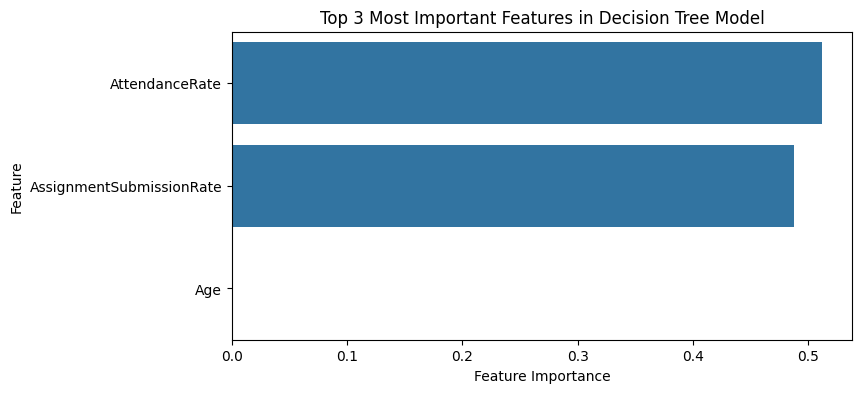

AttendanceRate is an important feature with importance score 0.5122.
AssignmentSubmissionRate is an important feature with importance score 0.4878.
Age is an important feature with importance score 0.0000.


In [33]:
# Get feature importance from the trained Decision Tree model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

top_features = feature_importance.head(3)

top_features


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 3 Most Important Features in Decision Tree Model")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

for index, row in top_features.iterrows():
    print(
        f"{row['Feature']} is an important feature with importance score "
        f"{row['Importance']:.4f}."
    )

# 3. Clustering Analysis

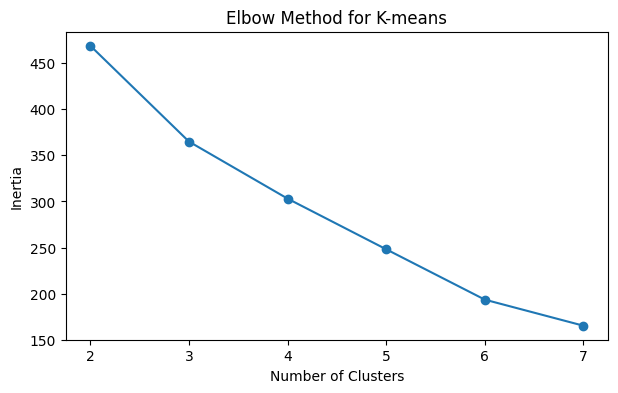

In [37]:
# Step 1: Import libraries

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 2: Prepare clustering dataframe

cluster_df = df.copy()

cluster_df = cluster_df.drop(
    columns=["StudentID", "GeneratedFeedback", "EngagementLevel"],
    errors="ignore"
)

if "SentimentScore" in cluster_df.columns:
    cluster_df["SentimentScore"] = (cluster_df["SentimentScore"] == "POSITIVE").astype(int)

cluster_df = pd.get_dummies(
    cluster_df,
    columns=["Program"],
    drop_first=False
)

# Remove target column because clustering is unsupervised
cluster_df = cluster_df.drop(columns=["EngagementLevel"], errors="ignore")

cluster_df.head()

# Step 3: Select suitable numerical features for clustering

X_cluster = cluster_df

# Step 4: Scale the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

# Step 5: Use elbow method to compare K values

inertia_scores = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=11,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia_scores.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-means")
plt.show()



In [40]:

kmeans_model = KMeans(
    n_clusters=3,
)

cluster_labels = kmeans_model.fit_predict(X_scaled)


In [61]:
df["Cluster"] = cluster_labels

# View number of students in each cluster

df["Cluster"].value_counts().sort_index()

# Compare clusters with actual EngagementLevel

cluster_engagement = pd.crosstab(
    df["Cluster"],
    df["EngagementLevel"]
)

cluster_engagement



EngagementLevel,High,Low,Medium
Cluster,,,
0,0,4,17
1,17,0,0
2,0,12,0


In [62]:
# Show percentage distribution of EngagementLevel in each cluster

cluster_engagement_percent = pd.crosstab(
    df["Cluster"],
    df["EngagementLevel"],
    normalize="index"
) * 100

cluster_engagement_percent


EngagementLevel,High,Low,Medium
Cluster,,,
0,0.0,19.047619,80.952381
1,100.0,0.000000,0.000000
2,0.0,100.000000,0.000000


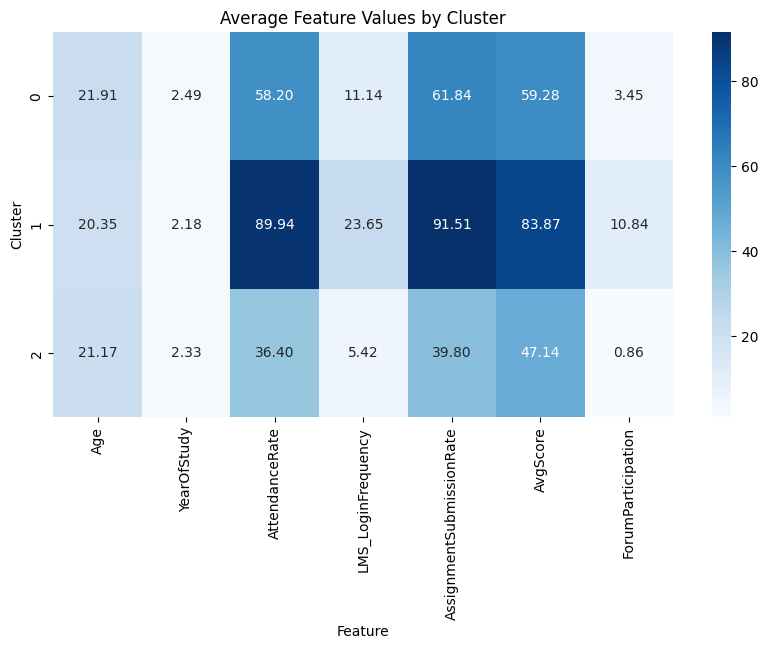


Cluster 0
AssignmentSubmissionRate    61.839919
AvgScore                    59.281385
AttendanceRate              58.203934
Age                         21.914480
LMS_LoginFrequency          11.143915
ForumParticipation           3.445887
YearOfStudy                  2.492711
Name: 0, dtype: float64

Cluster 1
AssignmentSubmissionRate    91.508135
AttendanceRate              89.941176
AvgScore                    83.866310
LMS_LoginFrequency          23.650980
Age                         20.352941
ForumParticipation          10.843583
YearOfStudy                  2.176471
Name: 1, dtype: float64

Cluster 2
AvgScore                    47.143939
AssignmentSubmissionRate    39.803191
AttendanceRate              36.396739
Age                         21.166667
LMS_LoginFrequency           5.418519
YearOfStudy                  2.333333
ForumParticipation           0.861742
Name: 2, dtype: float64


In [44]:

# Show average characteristics of each cluster

cluster_profile = df.groupby("Cluster")[
    [
        "Age",
        "YearOfStudy",
        "AttendanceRate",
        "LMS_LoginFrequency",
        "AssignmentSubmissionRate",
        "AvgScore",
        "ForumParticipation"
    ]
].mean()

cluster_profile

# Optional: visualize average cluster profile

plt.figure(figsize=(10, 5))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Average Feature Values by Cluster")
plt.xlabel("Feature")
plt.ylabel("Cluster")

plt.show()

for cluster in cluster_profile.index:
    print(f"\nCluster {cluster}")
    print(cluster_profile.loc[cluster].sort_values(ascending=False))

# 4. Predictive Modelling with AI Integration

Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         3
         Low       1.00      0.67      0.80         3
      Medium       0.80      1.00      0.89         4

    accuracy                           0.90        10
   macro avg       0.93      0.89      0.90        10
weighted avg       0.92      0.90      0.90        10



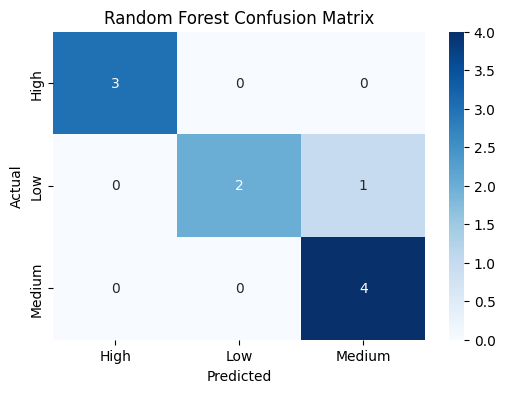

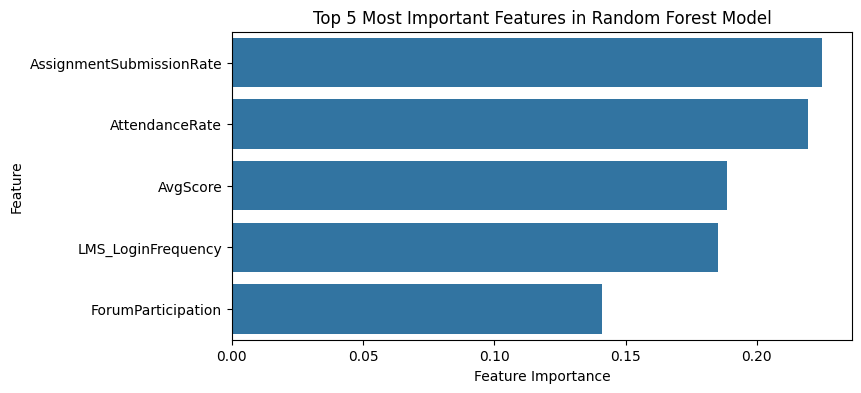

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Predicted Engagement Level: High

Class Probabilities:
High: 1.0000
Low: 0.0000
Medium: 0.0000

Top Important Features:
                    Feature  Importance
5  AssignmentSubmissionRate    0.224969
3            AttendanceRate    0.219420
6                  AvgScore    0.188655

Student Values for Top Features:
{'AssignmentSubmissionRate': np.float64(95.0), 'AttendanceRate': np.float64(92.0), 'AvgScore': np.float64(88.0)}
----------------------------------------------------------------------------------------------------

Explanation: The student was classified as High Engagement because the Random Forest model predicted it with a probability of 1.00 and the most influential features were AssignmentSubmissionRate, AttendanceRate, and AvgScore, which all had high values for this student. Random Forest makes predictions by combining many decision trees, and in this case, the decision trees determined that the student's high values for these features indicate high engagement.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    random_state=11
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

# Feature Importance for Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

# Plot top 5 important features

top_features = feature_importance.head(5)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 5 Most Important Features in Random Forest Model")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

# Function to get Random Forest prediction explanation data

def get_random_forest_explanation(model, X, row_index, target_encoder, top_n=3):
    student_data = X.iloc[[row_index]]

    prediction_encoded = model.predict(student_data)[0]
    prediction_label = target_encoder.inverse_transform([prediction_encoded])[0]

    prediction_proba = model.predict_proba(student_data)[0]
    class_probabilities = {
        target_encoder.classes_[i]: prediction_proba[i]
        for i in range(len(target_encoder.classes_))
    }

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    top_features = feature_importance.head(top_n)

    student_feature_values = {
        feature: student_data.iloc[0][feature]
        for feature in top_features["Feature"]
    }

    return prediction_label, class_probabilities, top_features, student_feature_values

# Choose one student to explain

row_index = 0

prediction_label, class_probabilities, top_features, student_feature_values = get_random_forest_explanation(
    rf_model,
    X,
    row_index,
    target_encoder,
    top_n=3
)

print("Predicted Engagement Level:", prediction_label)
print("\nClass Probabilities:")
for label, prob in class_probabilities.items():
    print(f"{label}: {prob:.4f}")

print("\nTop Important Features:")
print(top_features)

print("\nStudent Values for Top Features:")
print(student_feature_values)

def make_explanation_prompt(row_index, prediction_label, class_probabilities, top_features, student_feature_values):
    probabilities_text = "\n".join([
        f"- {label}: {prob:.2f}"
        for label, prob in class_probabilities.items()
    ])

    top_features_text = "\n".join([
        f"- {row['Feature']} with importance {row['Importance']:.4f}"
        for _, row in top_features.iterrows()
    ])

    student_values_text = "\n".join([
        f"- {feature}: {value}"
        for feature, value in student_feature_values.items()
    ])

    prompt = f"""[INST]
You are explaining a Random Forest model prediction.

The model predicted this student as: {prediction_label} Engagement.

Prediction probabilities:
{probabilities_text}

Most influential features in the Random Forest model:
{top_features_text}

This student's values for those influential features:
{student_values_text}

Write exactly 2 simple sentences explaining why the student was classified as {prediction_label} Engagement.
Only use the information provided above. Do not add unsupported reasons.
[/INST]"""

    return prompt

# Generate explanation using your existing Mistral generator

prompt = make_explanation_prompt(
    row_index,
    prediction_label,
    class_probabilities,
    top_features,
    student_feature_values
)

explanation = generator(
    prompt,
    max_new_tokens=120,
    do_sample=False,
    return_full_text=False
)[0]["generated_text"].strip()

print("-" * 100)
print()
print(f"Explanation: {explanation}")

In [69]:
def make_explanation_prompt(row_index, prediction_label, rules):
    rules_text = "\n".join([f"- {rule}" for rule in rules])

    prompt = f"""[INST]
You are explaining a Decision Tree model prediction.

The model predicted this student as: {prediction_label} Engagement.

Decision Tree rules used for this prediction:
{rules_text}

Write exactly 2 simple sentences explaining why the student was classified as {prediction_label} Engagement.
Only use the rules above. Do not add unsupported reasons.
[/INST]"""

    return prompt

prompt = make_explanation_prompt(row_index, prediction_label, rules)

explanation = generator(
    prompt,
    max_new_tokens=100,
    do_sample=False,
    return_full_text=False
)[0]["generated_text"].strip()

print('-' * 100)
print('\n')
print(f'Explanation: {explanation}')

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


----------------------------------------------------------------------------------------------------


Explanation: Based on the Decision Tree model's rules, the student was classified as High Engagement because their AttendanceRate was greater than 77.50. This indicates that the student consistently attended class and was actively engaged in the learning process.
